Лабораторная работа №3. Арифметические вычисления.

---



In [ ]:
import random as rd
import pandas as pd
import math

Variant = 14
rd.seed(Variant)

set_operations = ['-','+','*','/']
set_operands = ['a', 'b', 'c']
count_operations = rd.randint(3,5)

expression = set_operands[rd.randint(0,len(set_operands)-1)]
for i in range(count_operations):
    current_operation = set_operations[rd.randint(0,len(set_operations)-1)]
    current_operand = set_operands[rd.randint(0,len(set_operands)-1)]
    expression = "(" + expression + current_operation + current_operand + ")"
print(expression)


(((c+b)*b)-c)


1. На языке ассемблера реализовать программу, которая по введенному символу печатает его ASCII-код. Символ передавать в исполняемую программу как параметр командной строки.

In [ ]:
format ELF64

public _start
public exit
public print_itoa

section '.data' writable
    nl db 10

section '.bss' writable
    string rb 4

section '.text' executable
    _start:
        pop rax ; извлекаем из стека количество переданных аргументов командной строки
        cmp rax, 2 ; если меньше 2, выходим
        jl exit

        pop rbx ; извлекаем имя программы
        pop rdi ; извлекаем адрес первого байта переданного символа
        xor rbx, rbx

        mov bl, byte [rdi] ; кладем в bl ASCII-код символа
        call print_itoa
        jmp exit

print_itoa:
    push rax ; пушим все регистры в стек, чтобы не изменять внешнее состояние программы
    push rdi
    push rsi
    push rcx
    push rdx
    mov rdx, 10 ; делитель
    xor rcx, rcx
    xor rax, rax
    mov ax, bx ; кладем делимое в ax
    @@: ; безымянная метка
        xor ah, ah ; обнуляем старшую часть делимого перед делением
        div dl ; беззнаковое деление на 10
        add ah, '0' ; переводим каждую цифру ASCII-кода в символ (ASCII-код символа)
        mov [string + rcx], ah ; помещаем в буфер строки для дальнейшего вывода
        inc rcx
        cmp al, 0 ; пока частное от деления не обнулится
        ja @b ; переходим на ближайшую сзади безымянную метку

    @@:
        dec rcx
        mov rax, string
        add rax, rcx
        mov rdi, 1
        mov rsi, rax
        mov rax, 1
        mov rdx, 1 ; побайтовый вывод строки с конца (в правильной последовательности цифр)
        push rcx
        syscall
        pop rcx
        cmp rcx, 0
        ja @b

    mov rax, 1
    mov rdi, 1
    mov rsi, nl ; переход на следующую строку
    mov rdx, 1
    syscall

    pop rdx
    pop rcx
    pop rsi ; возвращаем обратно исходные значения в регистрах
    pop rdi
    pop rax
    ret

exit:
    mov rax, 60
    mov rdi, 0
    syscall


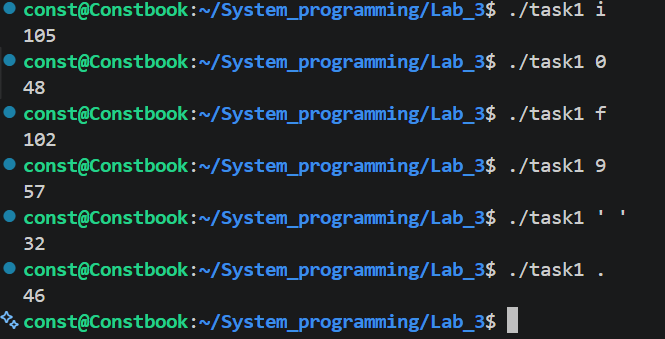

2. Разработать программу на языке ассемблера, в которой в соответствии с вариантом выполнить расчет значения арифметического выражения и вывести результат на экран, операторы для арифметического выражения a, b, c передаются исполняемой программе как параметры командной строки.

In [ ]:
format ELF64

public _start
public func_atoi
public calculate
public print_itoa
public exit

section '.data' writable
    nl db 10

section '.bss' writable
    result rb 20

section '.text' executable
    _start:
        pop rax
        cmp rax, 3
        jl exit

        pop rdx ; имя исполняемого файла
        pop rdi ; указатель на строку с первым операндом - b
        pop rsi ; указатель на строку со вторым операндом - c
        xor rbx, rbx
        xor rcx, rcx

        call func_atoi ; на вход передается адрес первого байта первого аргумента в rdi
        mov rbx, rax ; сохраняем первый операнд в rbx

        mov rdi, rsi ; кладем адрес первого байта второго аргумента в rdi
        call func_atoi
        mov rcx, rax ; сохраняем второй операнд в rcx

        call calculate ; находим значение арифметического выражения
        jmp exit

func_atoi: ; парсит число из строки, принимая адрес начала строки в rdi и аккумулируя число в rax
    push r8
    push rbx
    push rcx
    push rsi

    xor rax, rax ; на выходе в rax будет лежать наше число
    xor rbx, rbx
    mov rbx, 10
    xor rcx, rcx
    @@: ; безымянная метка
        xor r8, r8
        mov r8b, byte [rdi + rcx] ; кладем каждый символ по адресу, начиная с rdi

        cmp r8, '0' ; проверяем, принадлежит ли символ нашему числу
        jb @f ; если это, к примеру, ' ', то переходим на ближайшую безымянную метку впереди
        cmp r8, '9'
        ja @f ; аналогично, это значит, что число уже сформировалось

        sub r8, '0' ; получаем саму цифру числа
        mul rbx ; умножает значение в rax на 10
        add rax, r8 ; и прибавляет следующую цифру, аккумулируя число
        inc rcx
        jmp @b ; переходим на ближайшую безымянную метку сзади, то есть на следующую итерацию цикла

    @@: ; безымянная метка
        pop rsi
        pop rcx
        pop rbx
        pop r8
        ret

calculate: ; считает значение арифметического выражения, сохраняя его в регистр rax
    push rax
    push rdx
    push rdi
    push rsi

    xor rax, rax
    mov rax, rcx
    add rax, rbx
    mul rbx
    sub rax, rcx
    call print_itoa ; и передаем управление функции вывода
    pop rsi
    pop rdi
    pop rdx
    pop rax
    ret ; берет из верхушки стека адрес возврата и переходит по нему

print_itoa: ; переводит число в последовательность символов, которую записывает в буфер для дальнейшего вывода на экран
    push rbx
    push rdi
    push rsi
    push rcx
    push rdx
    xor rbx, rbx
    mov rbx, 10
    xor rcx, rcx
    @@: ; безымянная метка
        xor rdx, rdx ; очищаем для остатка
        div rbx ; 8-байтовый делитель
        add rdx, '0' ; переводим каждую цифру в символ
        mov [result + rcx], dl ; записываем в обратном порядке в буфер
        inc rcx
        cmp rax, 0 ; пока частное не обнулится
        ja @b

    @@: ; безымянная метка
        dec rcx
        mov rax, result
        add rax, rcx
        mov rdi, 1
        mov rsi, rax
        mov rax, 1
        mov rdx, 1
        push rcx
        syscall ; побайтовый вывод ответа из буфера
        pop rcx
        cmp rcx, 0
        ja @b ; переход на ближайшую безымянную метку назад

    mov rax, 1
    mov rdi, 1
    mov rsi, nl ; вывод \n
    mov rdx, 1
    syscall

    pop rdx
    pop rcx
    pop rsi
    pop rdi
    pop rbx
    ret

exit:
    mov rax, 60
    mov rdi, 0
    syscall


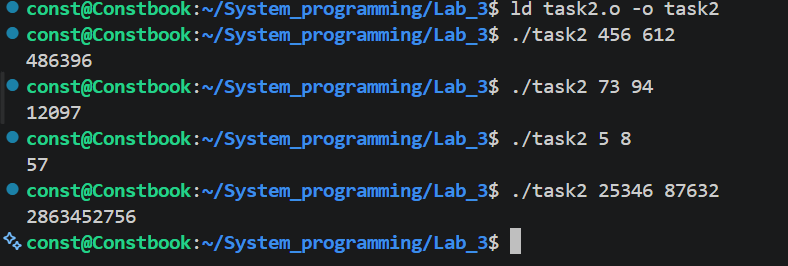

3. На языке программирования С составить аналогичную п.2 программу, сверить полученные результаты.

In [ ]:
#include <stdio.h>
#include <stdlib.h>

int main(int argc, char *argv[]) {
    if (argc < 3) {
        printf("two arguments needed\n");
        return 1;
    }

    unsigned int b = atoi(argv[1]);
    unsigned int c = atoi(argv[2]);
    unsigned int result = (((c + b) * b) - c);

    printf("%u\n", result);

    return 0;
}


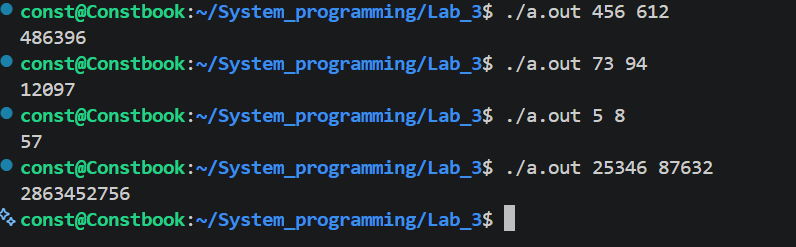